# Correlation Plots (Natural vs Incentivised)

In [ ]:
%%capture
# If getting 'Could not find project LASR_probe_gen' get key from https://wandb.ai/authorize and paste below
import os
os.environ["WANDB_SILENT"] = "true"
import wandb
wandb.login(key="2515140fe66df7aef4054b8a4200835635960747")

## Varying Probe

In [ ]:
from probe_gen.standard_experiments import get_bar_chart_results_table_from_wandb
from probe_gen.config import BEHAVIOUR_DATASOURCE_ACTMODEL_OFFPOLICYMODEL

train_OOD = False # Do we only care about ID training data?
activations_model = ["llama_3b", "ministral_8b"][0]
done_experiments = BEHAVIOUR_DATASOURCE_ACTMODEL_OFFPOLICYMODEL

probe_type = "mean"
# Get experiments into format
# [probe_type, behaviour, [ID datasource, OOD datasource], activations_model, [ID off_policy_model, OOD off_policy_model]]
train_setup = []
for behaviour in list(done_experiments.keys()):
    ds = list(done_experiments[behaviour].keys())[1:]
    off_mods = [done_experiments[behaviour][ds[0]][activations_model], done_experiments[behaviour][ds[1]][activations_model]]
    train_setup.append([probe_type, behaviour, [ds[0], ds[1]], activations_model, [off_mods[0], off_mods[1]]])
    if done_experiments[behaviour]["test_both"]:
        train_setup.append([probe_type, behaviour, [ds[1], ds[0]], activations_model, [off_mods[1], off_mods[0]]])
group_labels1 =  ['On-Policy Incentivised', 'On-Policy Prompted', 'Off-Policy']
train_gen_methods1 = ['incentivised', 'prompted', 'off_policy']
test_gen_method1 = 'incentivised'
results_table1 = get_bar_chart_results_table_from_wandb(train_setup, train_gen_methods1, test_gen_method1, train_OOD)
group_labels2 =  ['On-Policy Natural', 'On-Policy Incentivised', 'On-Policy Prompted', 'Off-Policy']
train_gen_methods2 = ['on_policy', 'incentivised', 'prompted', 'off_policy']
test_gen_method2 = 'on_policy'
results_table2 = get_bar_chart_results_table_from_wandb(train_setup, train_gen_methods2, test_gen_method2, train_OOD)

probe_type = "attention_torch"
# Get experiments into format
# [probe_type, behaviour, [ID datasource, OOD datasource], activations_model, [ID off_policy_model, OOD off_policy_model]]
train_setup = []
for behaviour in list(done_experiments.keys()):
    ds = list(done_experiments[behaviour].keys())[1:]
    off_mods = [done_experiments[behaviour][ds[0]][activations_model], done_experiments[behaviour][ds[1]][activations_model]]
    train_setup.append([probe_type, behaviour, [ds[0], ds[1]], activations_model, [off_mods[0], off_mods[1]]])
    if done_experiments[behaviour]["test_both"]:
        train_setup.append([probe_type, behaviour, [ds[1], ds[0]], activations_model, [off_mods[1], off_mods[0]]])
group_labels3 =  ['On-Policy Incentivised', 'On-Policy Prompted', 'Off-Policy']
train_gen_methods3 = ['incentivised', 'prompted', 'off_policy']
test_gen_method3 = 'incentivised'
results_table3 = get_bar_chart_results_table_from_wandb(train_setup, train_gen_methods3, test_gen_method3, train_OOD)
group_labels4 =  ['On-Policy Natural', 'On-Policy Incentivised', 'On-Policy Prompted', 'Off-Policy']
train_gen_methods4 = ['on_policy', 'incentivised', 'prompted', 'off_policy']
test_gen_method4 = 'on_policy'
results_table4 = get_bar_chart_results_table_from_wandb(train_setup, train_gen_methods4, test_gen_method4, train_OOD)

In [ ]:
# One row for each policy, one column for each behaviour
results_table1

array([[0.922096, 0.915548, 0.979532, 0.949972, 0.897628, 0.96826 ,
        0.825648, 0.762924],
       [0.940028, 0.921936, 0.973008, 0.937852, 0.897444, 0.552792,
        0.755644, 0.551816],
       [0.93076 , 0.909444, 0.958092, 0.938968, 0.875124, 0.5781  ,
        0.781336, 0.585416]])

In [ ]:
# One row for each policy, one column for each behaviour
results_table2

array([[0.908516, 0.967836, 0.931252, 0.951348, 0.9221  , 0.912616,
        0.802116, 0.831892],
       [0.913076, 0.948592, 0.9186  , 0.9483  , 0.908056, 0.712392,
        0.822276, 0.688992],
       [0.9131  , 0.964864, 0.929584, 0.948672, 0.90192 , 0.865556,
        0.736316, 0.589416],
       [0.90924 , 0.966144, 0.925816, 0.951204, 0.887508, 0.757776,
        0.74794 , 0.636952]])

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

train_policy = ["prompted", "off_policy"][1] # Which policy results to plot?

# Keep only the right data
if train_policy == "prompted":
    x1 = np.array(results_table2[-2])
    y1 = np.array(results_table1[-2])
    x2 = np.array(results_table4[-2])
    y2 = np.array(results_table3[-2])
elif train_policy == "off_policy":
    x1 = np.array(results_table2[-1])
    y1 = np.array(results_table1[-1])
    x2 = np.array(results_table4[-1])
    y2 = np.array(results_table3[-1])

# Fit lines
slope1, intercept1 = np.polyfit(x1, y1, 1)
slope2, intercept2 = np.polyfit(x2, y2, 1)
slope_combined, intercept_combined = np.polyfit(np.concatenate([x1, x2]), np.concatenate([y1, y2]), 1)

y1_pred = slope1 * x1 + intercept1
y2_pred = slope2 * x2 + intercept2
y_combined_pred = slope_combined * np.concatenate([x1, x2]) + intercept_combined

# Compute R² values
r2_1 = 1 - np.sum((y1 - y1_pred)**2) / np.sum((y1 - np.mean(y1))**2)
r2_2 = 1 - np.sum((y2 - y2_pred)**2) / np.sum((y2 - np.mean(y2))**2)
r2_combined = 1 - np.sum((np.concatenate([y1, y2]) - y_combined_pred)**2) / np.sum((np.concatenate([y1, y2]) - np.mean(np.concatenate([y1, y2])))**2)

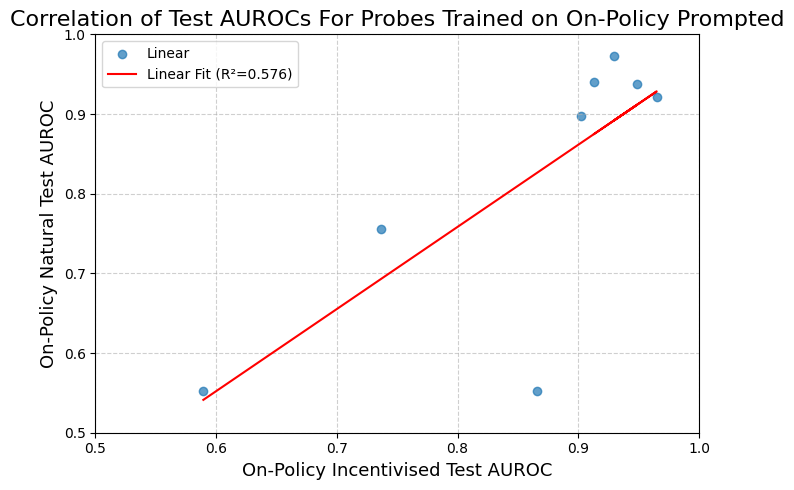

In [ ]:
plt.figure(figsize=(7, 5))

plt.scatter(x1, y1, label='Linear', alpha=0.7)
plt.plot(x1, y1_pred, color='red', label=f'Linear Fit (R²={r2_1:.3f})')

plt.xlabel('On-Policy Incentivised Test AUROC', fontsize=13)
plt.ylabel('On-Policy Natural Test AUROC', fontsize=13)
plt.title(f'Correlation of Test AUROCs For Probes Trained on {"On-Policy Prompted" if train_policy == "prompted" else "Off-Policy"}', fontsize=16)
plt.legend()

plt.xlim(0.5, 1.0)
plt.ylim(0.5, 1.0)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

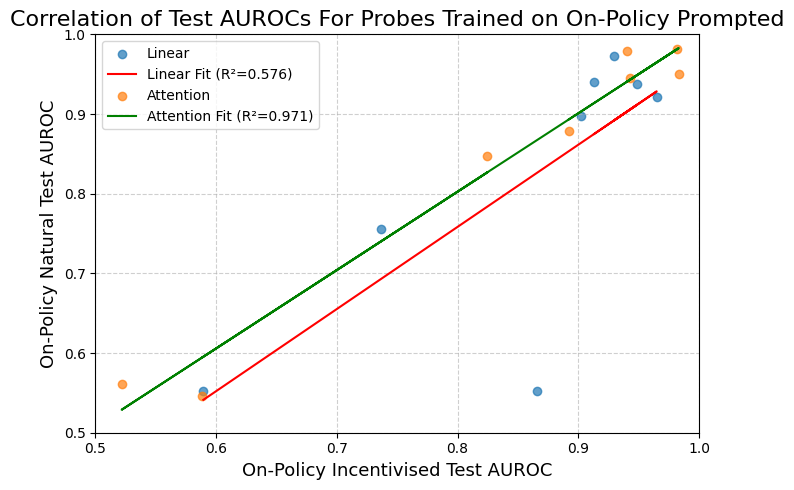

In [ ]:
plt.figure(figsize=(7, 5))

plt.scatter(x1, y1, label='Linear', alpha=0.7)
plt.plot(x1, y1_pred, color='red', label=f'Linear Fit (R²={r2_1:.3f})')
plt.scatter(x2, y2, label='Attention', alpha=0.7)
plt.plot(x2, y2_pred, color='green', label=f'Attention Fit (R²={r2_2:.3f})')

plt.xlabel('On-Policy Incentivised Test AUROC', fontsize=13)
plt.ylabel('On-Policy Natural Test AUROC', fontsize=13)
plt.title(f'Correlation of Test AUROCs For Probes Trained on {"On-Policy Prompted" if train_policy == "prompted" else "Off-Policy"}', fontsize=16)
plt.legend()

plt.xlim(0.5, 1.0)
plt.ylim(0.5, 1.0)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

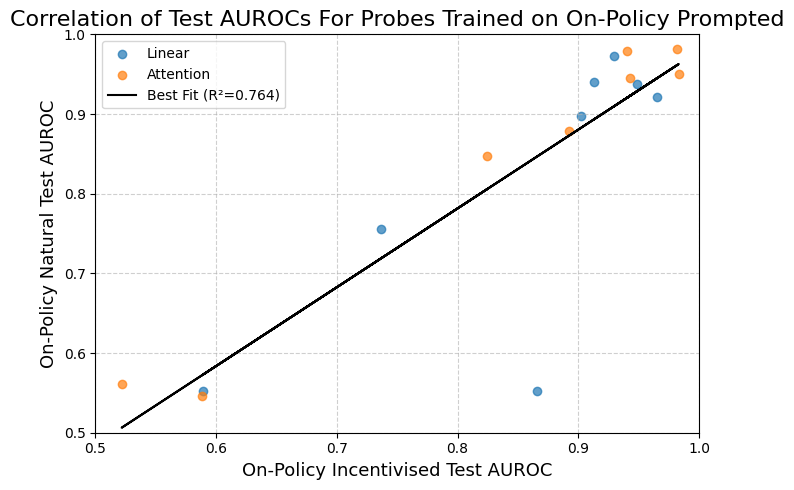

In [ ]:
plt.figure(figsize=(7, 5))

plt.scatter(x1, y1, label='Linear', alpha=0.7)
plt.scatter(x2, y2, label='Attention', alpha=0.7)
plt.plot(np.concatenate([x1, x2]), y_combined_pred, color='black', label=f'Best Fit (R²={r2_combined:.3f})')

plt.xlabel('On-Policy Incentivised Test AUROC', fontsize=13)
plt.ylabel('On-Policy Natural Test AUROC', fontsize=13)
plt.title(f'Correlation of Test AUROCs For Probes Trained on {"On-Policy Prompted" if train_policy == "prompted" else "Off-Policy"}', fontsize=16)
plt.legend()

plt.xlim(0.5, 1.0)
plt.ylim(0.5, 1.0)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Varying Act Model

In [ ]:
from probe_gen.standard_experiments import get_bar_chart_results_table_from_wandb
from probe_gen.config import BEHAVIOUR_DATASOURCE_ACTMODEL_OFFPOLICYMODEL

train_OOD = False # Do we only care about ID training data?
probe_type = ["mean", "attention_torch"][0]
done_experiments = BEHAVIOUR_DATASOURCE_ACTMODEL_OFFPOLICYMODEL

activations_model = "llama_3b"
# Get experiments into format
# [probe_type, behaviour, [ID datasource, OOD datasource], activations_model, [ID off_policy_model, OOD off_policy_model]]
train_setup = []
for behaviour in list(done_experiments.keys()):
    ds = list(done_experiments[behaviour].keys())[1:]
    off_mods = [done_experiments[behaviour][ds[0]][activations_model], done_experiments[behaviour][ds[1]][activations_model]]
    train_setup.append([probe_type, behaviour, [ds[0], ds[1]], activations_model, [off_mods[0], off_mods[1]]])
    if done_experiments[behaviour]["test_both"]:
        train_setup.append([probe_type, behaviour, [ds[1], ds[0]], activations_model, [off_mods[1], off_mods[0]]])
group_labels1 =  ['On-Policy Incentivised', 'On-Policy Prompted', 'Off-Policy']
train_gen_methods1 = ['incentivised', 'prompted', 'off_policy']
test_gen_method1 = 'incentivised'
results_table1 = get_bar_chart_results_table_from_wandb(train_setup, train_gen_methods1, test_gen_method1, train_OOD)
group_labels2 =  ['On-Policy Natural', 'On-Policy Incentivised', 'On-Policy Prompted', 'Off-Policy']
train_gen_methods2 = ['on_policy', 'incentivised', 'prompted', 'off_policy']
test_gen_method2 = 'on_policy'
results_table2 = get_bar_chart_results_table_from_wandb(train_setup, train_gen_methods2, test_gen_method2, train_OOD)

activations_model = "ministral_8b"
# Get experiments into format
# [probe_type, behaviour, [ID datasource, OOD datasource], activations_model, [ID off_policy_model, OOD off_policy_model]]
train_setup = []
for behaviour in list(done_experiments.keys()):
    ds = list(done_experiments[behaviour].keys())[1:]
    off_mods = [done_experiments[behaviour][ds[0]][activations_model], done_experiments[behaviour][ds[1]][activations_model]]
    train_setup.append([probe_type, behaviour, [ds[0], ds[1]], activations_model, [off_mods[0], off_mods[1]]])
    if done_experiments[behaviour]["test_both"]:
        train_setup.append([probe_type, behaviour, [ds[1], ds[0]], activations_model, [off_mods[1], off_mods[0]]])
group_labels3 =  ['On-Policy Incentivised', 'On-Policy Prompted', 'Off-Policy']
train_gen_methods3 = ['incentivised', 'prompted', 'off_policy']
test_gen_method3 = 'incentivised'
results_table3 = get_bar_chart_results_table_from_wandb(train_setup, train_gen_methods3, test_gen_method3, train_OOD)
group_labels4 =  ['On-Policy Natural', 'On-Policy Incentivised', 'On-Policy Prompted', 'Off-Policy']
train_gen_methods4 = ['on_policy', 'incentivised', 'prompted', 'off_policy']
test_gen_method4 = 'on_policy'
results_table4 = get_bar_chart_results_table_from_wandb(train_setup, train_gen_methods4, test_gen_method4, train_OOD)

In [ ]:
# One row for each policy, one column for each behaviour
results_table1

array([[0.922096, 0.915548, 0.979532, 0.949972, 0.897628, 0.96826 ,
        0.825648, 0.762924],
       [0.940028, 0.921936, 0.973008, 0.937852, 0.897444, 0.552792,
        0.755644, 0.551816],
       [0.93076 , 0.909444, 0.958092, 0.938968, 0.875124, 0.5781  ,
        0.781336, 0.585416]])

In [ ]:
# One row for each policy, one column for each behaviour
results_table2

array([[0.908516, 0.967836, 0.931252, 0.951348, 0.9221  , 0.912616,
        0.802116, 0.831892],
       [0.913076, 0.948592, 0.9186  , 0.9483  , 0.908056, 0.712392,
        0.822276, 0.688992],
       [0.9131  , 0.964864, 0.929584, 0.948672, 0.90192 , 0.865556,
        0.736316, 0.589416],
       [0.90924 , 0.966144, 0.925816, 0.951204, 0.887508, 0.757776,
        0.74794 , 0.636952]])

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

train_policy = ["prompted", "off_policy"][1] # Which policy results to plot?

# Keep only the right data
if train_policy == "prompted":
    x1 = np.array(results_table2[-2])
    y1 = np.array(results_table1[-2])
    x2 = np.array(results_table4[-2])
    y2 = np.array(results_table3[-2])
elif train_policy == "off_policy":
    x1 = np.array(results_table2[-1])
    y1 = np.array(results_table1[-1])
    x2 = np.array(results_table4[-1])
    y2 = np.array(results_table3[-1])

# Fit lines
slope1, intercept1 = np.polyfit(x1, y1, 1)
slope2, intercept2 = np.polyfit(x2, y2, 1)
slope_combined, intercept_combined = np.polyfit(np.concatenate([x1, x2]), np.concatenate([y1, y2]), 1)

y1_pred = slope1 * x1 + intercept1
y2_pred = slope2 * x2 + intercept2
y_combined_pred = slope_combined * np.concatenate([x1, x2]) + intercept_combined

# Compute R² values
r2_1 = 1 - np.sum((y1 - y1_pred)**2) / np.sum((y1 - np.mean(y1))**2)
r2_2 = 1 - np.sum((y2 - y2_pred)**2) / np.sum((y2 - np.mean(y2))**2)
r2_combined = 1 - np.sum((np.concatenate([y1, y2]) - y_combined_pred)**2) / np.sum((np.concatenate([y1, y2]) - np.mean(np.concatenate([y1, y2])))**2)

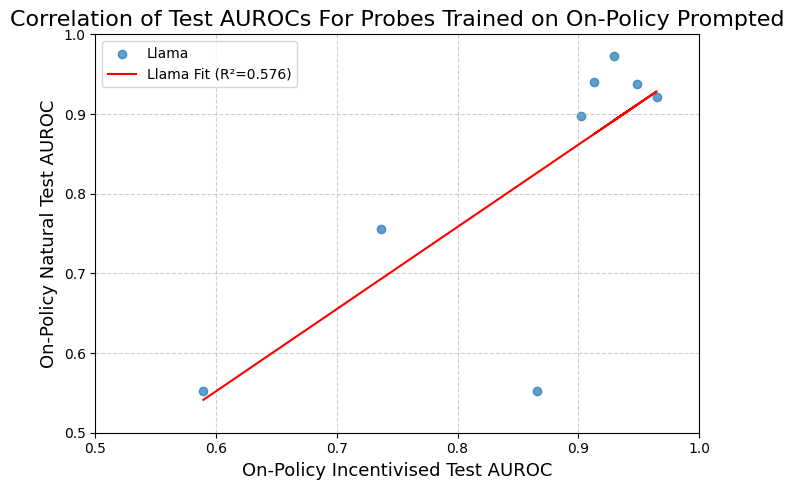

In [ ]:
plt.figure(figsize=(7, 5))

plt.scatter(x1, y1, label='Llama', alpha=0.7)
plt.plot(x1, y1_pred, color='red', label=f'Llama Fit (R²={r2_1:.3f})')

plt.xlabel('On-Policy Incentivised Test AUROC', fontsize=13)
plt.ylabel('On-Policy Natural Test AUROC', fontsize=13)
plt.title(f'Correlation of Test AUROCs For Probes Trained on {"On-Policy Prompted" if train_policy == "prompted" else "Off-Policy"}', fontsize=16)
plt.legend()

plt.xlim(0.5, 1.0)
plt.ylim(0.5, 1.0)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

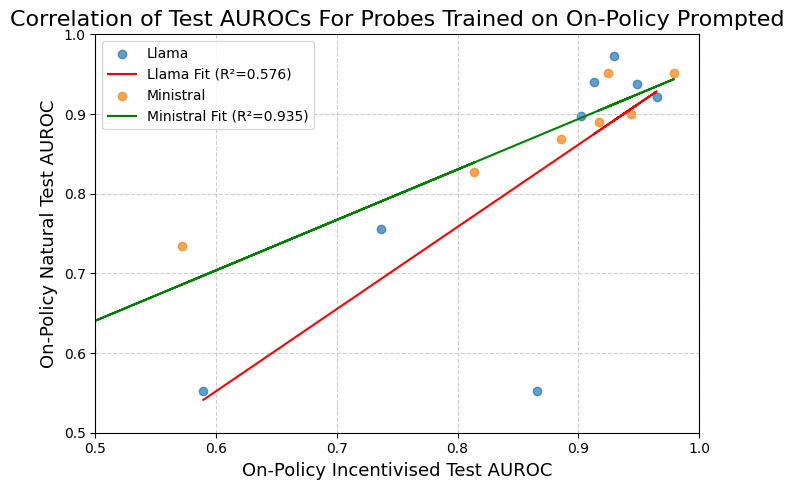

In [ ]:
plt.figure(figsize=(7, 5))

plt.scatter(x1, y1, label='Llama', alpha=0.7)
plt.plot(x1, y1_pred, color='red', label=f'Llama Fit (R²={r2_1:.3f})')
plt.scatter(x2, y2, label='Ministral', alpha=0.7)
plt.plot(x2, y2_pred, color='green', label=f'Ministral Fit (R²={r2_2:.3f})')

plt.xlabel('On-Policy Incentivised Test AUROC', fontsize=13)
plt.ylabel('On-Policy Natural Test AUROC', fontsize=13)
plt.title(f'Correlation of Test AUROCs For Probes Trained on {"On-Policy Prompted" if train_policy == "prompted" else "Off-Policy"}', fontsize=16)
plt.legend()

plt.xlim(0.5, 1.0)
plt.ylim(0.5, 1.0)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

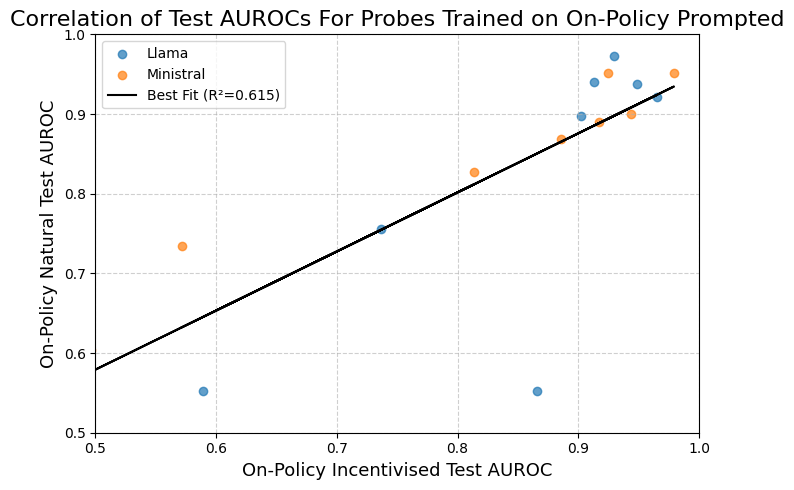

In [ ]:
plt.figure(figsize=(7, 5))

plt.scatter(x1, y1, label='Llama', alpha=0.7)
plt.scatter(x2, y2, label='Ministral', alpha=0.7)
plt.plot(np.concatenate([x1, x2]), y_combined_pred, color='black', label=f'Best Fit (R²={r2_combined:.3f})')

plt.xlabel('On-Policy Incentivised Test AUROC', fontsize=13)
plt.ylabel('On-Policy Natural Test AUROC', fontsize=13)
plt.title(f'Correlation of Test AUROCs For Probes Trained on {"On-Policy Prompted" if train_policy == "prompted" else "Off-Policy"}', fontsize=16)
plt.legend()

plt.xlim(0.5, 1.0)
plt.ylim(0.5, 1.0)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("correlation_plot.pdf", format="pdf", bbox_inches="tight")
plt.show()